In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.centralised import P4

In [2]:
# Demo experiment
market_size = 150
seed = 25
G = nx.gnp_random_graph(market_size, 0.11, seed=seed)
# nx.draw(G)
# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
M1: Market = Market(market_size, graph=G, seed=seed, agent_type=BaseAgent)
M2: Market = Market(market_size, graph=G, seed=seed, agent_type=ProportionalAgent)
M3: Market = Market(market_size, graph=G, seed=seed, agent_type=EqualDivisionAgent)
M4: Market = Market(market_size, graph=G, seed=seed, agent_type=OptimalAgent)

In [3]:
allocation_matrix, utility_vector = computed_equilibrium = P4(M1)
optimal_agents: List[OptimalAgent] = M4.agents
for agent in optimal_agents:
    agent.set_allocation_matrix(allocation_matrix)

In [ ]:
simulation_length = 400
M1.set_market_equilibrium(allocation_matrix, utility_vector)
M2.set_market_equilibrium(allocation_matrix, utility_vector)
M3.set_market_equilibrium(allocation_matrix, utility_vector)
M4.set_market_equilibrium(allocation_matrix, utility_vector)
simulated_state_base = M1.simulate(simulation_length)
simulated_state_prop = M2.simulate(simulation_length)
simulated_state_equal = M3.simulate(simulation_length)
simulated_state_optimal = M4.simulate(
    simulation_length, use_average_in_market_loss=False
)

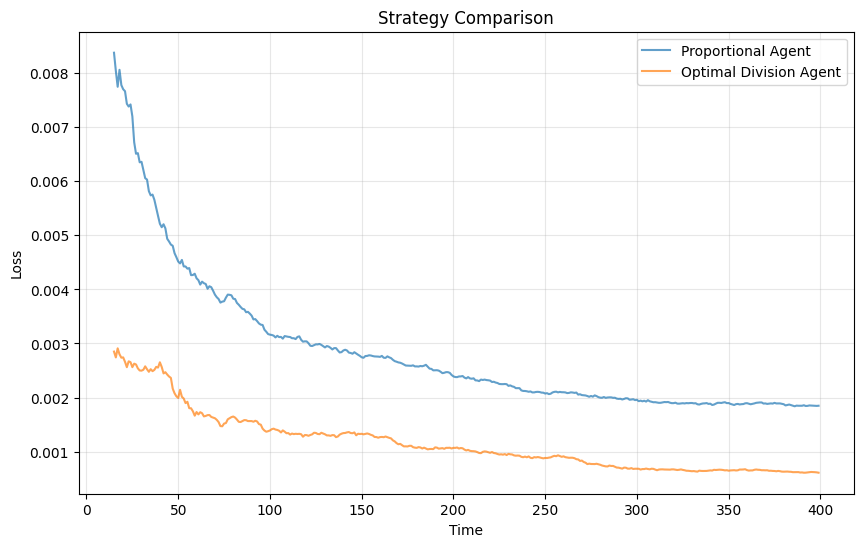

In [7]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))
# plt.plot(
#     time_steps, simulated_state_base[training_period:], label="Base Agent", alpha=0.7
# )
# plt.plot(
#     time_steps,
#     simulated_state_equal[training_period:],
#     label="Equal Division Agent",
#     alpha=0.7,
# )
plt.plot(
    time_steps,
    simulated_state_prop[training_period:],
    label="Proportional Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    simulated_state_optimal[training_period:],
    label="Optimal Division Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()